# AdaBoost Regression

AdaBoost is a boosting algorithm that combines multiple weak learners to create a strong predictive model. Each new learner focuses more on the errors made by the previous learner.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.ensemble import AdaBoostRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
project_root = Path.cwd().parent

train_path = project_root / "artifacts" / "data_transformation" / "train.npy"
test_path = project_root / "artifacts" / "data_transformation" / "test.npy"

train_arr = np.load(train_path)
test_arr = np.load(test_path)

In [3]:
X_train = train_arr[:, :-1]
y_train = train_arr[:, -1]   # The transformed arrays contain both the input features and the target variable.

X_test = test_arr[:, :-1]
y_test = test_arr[:, -1]

In [4]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(436, 14)
(436,)
(109, 14)
(109,)


In [5]:
model = AdaBoostRegressor(            #create model
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

print(model)

AdaBoostRegressor(n_estimators=100, random_state=42)


In [6]:
model.fit(X_train, y_train)                 # model train

print("AdaBoost model trained successfully!")

AdaBoost model trained successfully!


In [7]:
y_pred = model.predict(X_test)             #predict model

print(y_pred[:5])

[5827735.27777778 6960644.33701658 3516056.53594771 5177053.63636364
 3766719.62616822]


In [8]:
comparison = pd.DataFrame({        # compare actual vs predicted 
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,4060000.0,5.827735e+06
1,6650000.0,6.960644e+06
2,3710000.0,3.516057e+06
3,6440000.0,5.177054e+06
4,2800000.0,3.766720e+06
5,4900000.0,4.917366e+06
6,5250000.0,6.091134e+06
7,4543000.0,5.853050e+06
8,2450000.0,3.376500e+06
9,3353000.0,3.478786e+06


In [9]:
mae = mean_absolute_error(y_test, y_pred)               # evaluation

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2 Score : {r2:.4f}")

MAE : 1161961.94
MSE : 2270512530945.30
RMSE : 1506822.00
R2 Score : 0.5508


In [10]:
feature_names = [                  # feature names
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
    "furnishingstatus_furnished",
    "furnishingstatus_semi-furnished",
    "furnishingstatus_unfurnished",
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "parking"
]

In [11]:
importance = model.feature_importances_                  # feature importance

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
9,area,0.323572
11,bathrooms,0.170004
10,bedrooms,0.150931
13,parking,0.089613
4,airconditioning,0.054721
5,prefarea,0.046166
3,hotwaterheating,0.041553
1,guestroom,0.025748
7,furnishingstatus_semi-furnished,0.021608
2,basement,0.019901


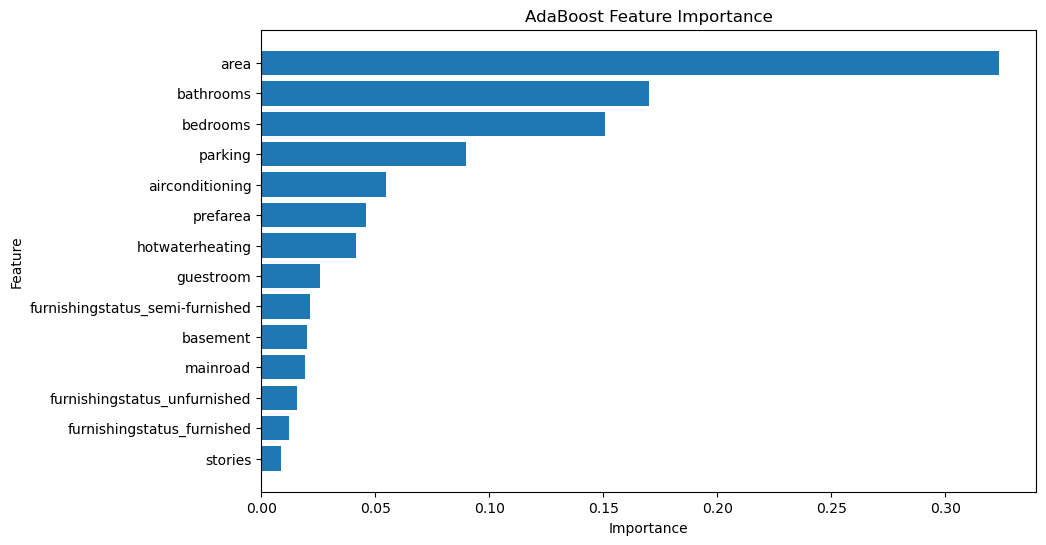

In [12]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("AdaBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()